# Lab 7: Ensembles

A ensemble is a collection of predictors that come together to give a final prediction. The reason we use ensembles is that many different predictors trying to predict the same thing will perform better than any single predictor alone. Besides, ensembles can counter some of the weaknesses of individual predictors (for example the overfitting on the decision trees). In this lab, we will explore three ensemble methods: Bagging, Random Forests and Boosting.

First, let's load the necessary libraries and create the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mode


# ML libraries to construct, use and analyse the trees
from sklearn.tree import export_graphviz, DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from io import StringIO
from IPython.display import Image
from sklearn.metrics import mean_squared_error, confusion_matrix
import pydotplus

from sklearn.metrics import mean_squared_error

First, load the `Carseat_clean.csv` dataset that contains information about car seat sales that has already been cleaned. We will try to predict wether the sales are high or not of different car seats.

In [2]:
# TODO Import and split the original data into training and test sets (use 50% of the data for testing and set random_state to 0)
carseats = pd.read_csv('https://raw.githubusercontent.com/cossorzano/COSS_DataAnalysis_notebooks/main/MachineLearning/02_Carseats_clean.csv', index_col=0)
X = carseats.iloc[:, :-1]
y = carseats.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)


| Column Name     | Meaning                                                                                                     |
| --------------- | -------------------------------------------------------------------------------------------------------------------- |
| **Sales**       | Unit sales (in thousands) at each store. This is typically the **response variable**.                                |
| **CompPrice**   | Price charged by a competing store for the same car seat.                                                            |
| **Income**      | Average income in the region (in thousands of dollars).                                                              |
| **Advertising** | Advertising budget at the store (in thousands of dollars).                                                           |
| **Population**  | Population size of the region where the store is located.                                                            |
| **Price**       | Price charged by the store for the car seat.                                                                         |
| **ShelveLoc**   | A categorical variable indicating the quality of the shelf location for the product (e.g., "Bad", "Medium", "Good"). |
| **Age**         | Average age of the local population.                                                                                 |
| **Education**   | Average education level in the area (likely in years).                                                               |
| **Urban**       | Whether the store is in an urban location ("Yes"/"No").                                                              |
| **US**          | Whether the store is in the US ("Yes"/"No").                                                                         |


In [3]:
carseats.head()

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high
0,138,73,11,276,120,0,42,17,0,0,1
1,111,48,16,260,83,1,65,10,0,0,1
2,113,35,10,269,80,2,59,12,0,0,1
3,117,100,4,466,97,2,55,14,0,0,0
4,141,64,3,340,128,0,38,13,0,1,0


## Bagging

Decision tree models usually suffer from high variance as well as overfitting. **B**ootstrap **agg**regation, or **bagging** usually helps with this issue as averaging a set of obsrvations reduces variance. To do bagging here, we will do it both by hand and by employing the sklearn function.

<p align="center">
    <img src="https://raw.githubusercontent.com/cossorzano/COSS_DataAnalysis_notebooks/main/MachineLearning/02_Bagging-classifier.png" alt="Bagging Classifier">
</p>

The bagging process is as follows:

1. Create many (e.g., 1000) subsets of our training set, each with 100 instances selected randomly with replacement.
2. Train one Decision Tree on each subset.
3. Make predictions by aggregating the predictions of all the Decision Trees.


First, let's go with the *by-hand* implementation

In [4]:
# Set the bagging parameters
n_estimators = 10  # Number of decision trees in the ensemble
df_len = len(X_train) # For a easy random selection of the data

# Store the predictions
predictions = []

for _ in range(n_estimators):

    # Create a bootstrap sample.
    bootstrap_indices = []
    for _ in range(df_len):
        bootstrap_indices.append(np.random.randint(0, df_len))

    X_bootstrap = carseats.iloc[bootstrap_indices, :-1]
    y_bootstrap = carseats.iloc[bootstrap_indices, -1]

    # Train a decision tree classifier on the bootstrap sample (impose no restrictions whatsoever)
    decision_tree = DecisionTreeClassifier()
    decision_tree.fit(X_bootstrap, y_bootstrap)

    # Make predictions on the test set using the trained decision tree
    y_pred = decision_tree.predict(X_test)
    predictions.append(y_pred)

# Combine predictions
# For classification, you can use majority voting, something related with fashion... (Take also the index 0)
majority_vote = mode(predictions)[0]

# For regression, you can use averaging although it won't be used on this practice
# combined_predictions = np.(predictions, axis=0)  # For classification, use np.mean for voting

print("The result of the decission tree is: ", majority_vote)

The result of the decission tree is:  [1 1 0 0 1 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 1 0 1 1 0 1 1 1 1 0 1 0
 0 0 0 0 0 0 1 1 0 1 1 1 1 0 1 1 1 0 1 0 1 1 0 0 1 0 0 0 1 1 1 0 0 1 1 1 0
 1 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 1 0 1 0 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1
 0 1 1 0 1 1 1 0 1 0 0 1 1 0 0 0 1 1 0 1 0 1 1 1 0 0 0 0 1 1 1 1 1 0 0 1 1
 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 1 0 1 0 0 1 0 0 0 1 0 1 0 1 0 1 0 0 1
 0 0 0 0 0 0 0 1 0 1 0 0 1 1 0]


Print the [binary confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html), remember that the function imported can be diferent from the one explained in class.

In [5]:
E = confusion_matrix(y_test, majority_vote)
print(E)
accuracy = E.diagonal().sum() / E.sum()
print(f"Accuracy: {accuracy:.2f}")

[[104  14]
 [ 11  71]]
Accuracy: 0.88


Let's see how this is done in `sklearn`... Fit it and show the confusion matrix

In [6]:
# Create a BaggingClassifier (fix random_state to 0)
bagging = BaggingClassifier(random_state=0, max_features=1.0, n_estimators=10)

# Train it with the training data
bagging.fit(X_train, y_train)

# Obtain the predictions
bagging_pred = bagging.predict(X_test)

# Print the confusion matrix
E = confusion_matrix(y_test, bagging_pred)
print(E)
accuracy = E.diagonal().sum() / E.sum()
print(f"Accuracy: {accuracy:.2f}")

[[97 21]
 [28 54]]
Accuracy: 0.76


**What model has a better performance? Calculate the metrics that you need to decide it and show your work**
> The accuracy of the manual model is 0.88 while the accuracy of the sklearn model is 0.76, therefore the manual model has a better performance.
Furthermore, looking at the confussion matrix as well as the f1 scores, the manual model generates more balanced predictions, while the sklearn model has a higher ammount of false negatives.

We will use the `sklearn` implementation to study the variable importance. *Make sure you understand how this is done!*

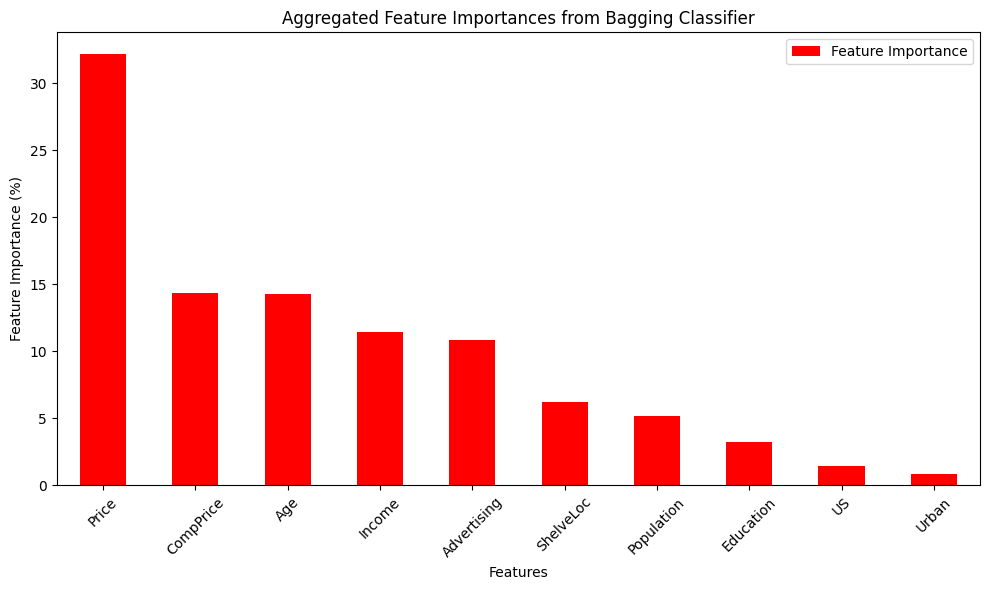

In [7]:
# Extract feature importances from each estimator in the bagging ensemble
importances = [est.feature_importances_ for est in bagging.estimators_ if hasattr(est, 'feature_importances_')]

# Calculate the mean of the feature importances across all estimators
mean_importances = np.mean(importances, axis=0)

# Create a DataFrame for the aggregated feature importances (converted to percentages)
bagging_featureImportance = pd.DataFrame({'Feature Importance': mean_importances * 100}, index=X.columns)

# Sort the DataFrame by feature importance in descending order
bagging_featureImportance = bagging_featureImportance.sort_values('Feature Importance', ascending=False)

# Plot the feature importances as a bar chart
ax = bagging_featureImportance.plot(kind='bar', color='red', figsize=(10, 6))
ax.set_xlabel('Features')
ax.set_ylabel('Feature Importance (%)')
ax.set_title('Aggregated Feature Importances from Bagging Classifier')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Could any of the features be eliminated? Would the model still have a good performance?**
> The Price feature can not be eliminated as it is the most important to determine the sales of a car seat, however all the features bellow income (included) could be eliminated without affecting the performance of the model.

## Random Forest

The random forest ensemble decorrelates the trees, by training them on random subsets of the features. This process is called *feature bagging*.

<p align="center">
    <img src="https://raw.githubusercontent.com/cossorzano/COSS_DataAnalysis_notebooks/main/MachineLearning/02_Random forest.png" alt="Random Forest">
</p>

The process is as follows:

1. Create a number of decision trees with different subsets of the features.
2. Train each tree on a different subset of the training data.
3. Make predictions by aggregating the predictions of all the Decision Trees.

In [8]:

# RF parameters
n_estimators = 10  # Number of decision trees in the forest

df_len = len(X_train) # For a easy random selection of the data
amount_features = int(np.sqrt(len(X.columns))) # For "the best" amount of features (without cross-validation)

# Train decision trees with random feature selection and make predictions
predictions = []
for _ in range(n_estimators):

    # Construct your own RF ensemble!
    bootstrap_indices = []
    for _ in range(df_len):
        bootstrap_indices.append(np.random.randint(0, df_len))

    X_bootstrap = carseats.iloc[bootstrap_indices, :-1]
    y_bootstrap = carseats.iloc[bootstrap_indices, -1]

    # Select a random subset of 4 features, the pop method over the columns of
    # the DataFrame may be useful
    features = []
    features = list(X_bootstrap.columns)
    for _ in range(amount_features):
        feature = features.pop(np.random.randint(0, len(features)))
        features.append(feature)

    # Train a decision tree classifier on the bootstrap sample (impose no restrictions whatsoever)
    decision_tree = DecisionTreeClassifier()
    decision_tree.fit(X_bootstrap[features], y_bootstrap)

    # Make predictions on the test set using the trained decision tree
    y_pred = decision_tree.predict(X_test[features])
    predictions.append(y_pred)

#  Finally, combine predictions using majority voting
majority_vote = mode(predictions)[0]

print("The result of the decission tree is: ", majority_vote)

The result of the decission tree is:  [0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 1 1 0 1 1 1 1 0 1 0
 0 0 1 0 0 0 1 1 0 1 1 1 1 0 1 1 1 0 1 0 1 1 0 1 1 0 0 0 1 1 1 0 0 1 1 1 0
 1 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 1
 0 1 1 0 0 1 1 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 1 1 0 1 0 0 1 1 1 1 1 0 0 1 1
 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 0 0 1 0 1 0 0 1 0 0 0 1 0 1 0 1 0 1 0 0 1
 0 1 0 1 0 0 0 1 0 1 0 0 1 1 0]


Print the confusion matrix

In [9]:
E = confusion_matrix(y_test, majority_vote)
print(E)
accuracy = E.diagonal().sum() / E.sum()
print(f"Accuracy: {accuracy:.2f}")

[[102  16]
 [ 12  70]]
Accuracy: 0.86


Let us do it again with `sklearn` so you see the differences... Show the confusion matrix. In this last part there may be some differences with your run, which are due to the randomness of the classifiers constructed. Do not worry too much about it here.

In [10]:
# Construct the RF classifier with RandomForestClassifier.
# Fix the random_state to 0, n_estimators to 10 and max_features to 0.8
rf = RandomForestClassifier(random_state=0, n_estimators=10, max_features=0.8)

# Train it
rf.fit(X_train, y_train)

# Predict the test values
rf_pred= rf.predict(X_test)

# Obtain the confusion matrix and print it
E = confusion_matrix(y_test, rf_pred)
print(E)
accuracy = E.diagonal().sum() / E.sum()
print(f"Accuracy: {accuracy:.2f}")

[[103  15]
 [ 34  48]]
Accuracy: 0.76


Using again the `sklearn` implementation, we will study the feature importance

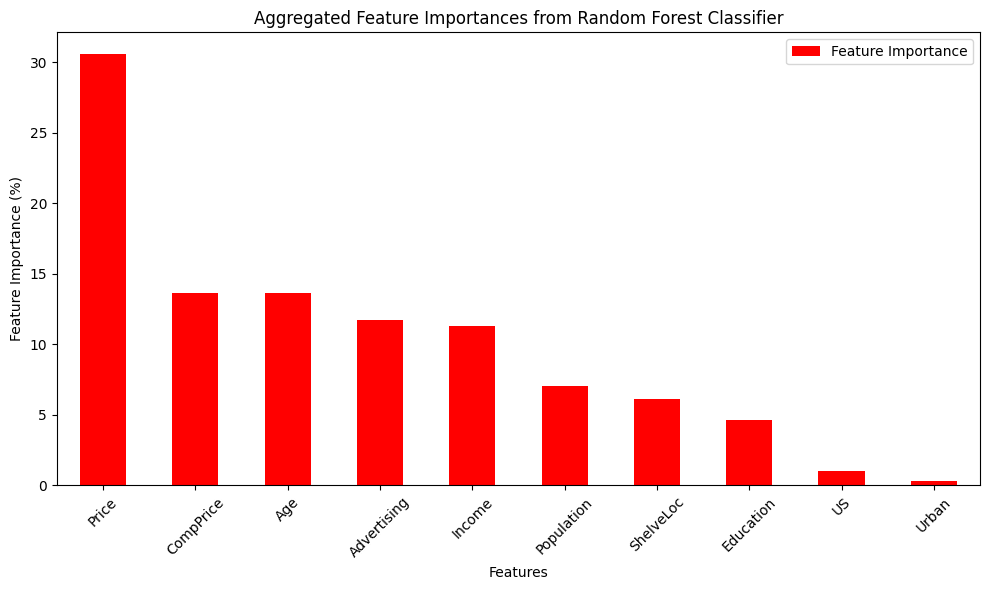

In [11]:
# Extract feature importances from each estimator in the bagging ensemble
importances = [est.feature_importances_ for est in rf.estimators_ if hasattr(est, 'feature_importances_')]

# Calculate the mean of the feature importances across all estimators
mean_importances = np.mean(importances, axis=0)

# Create a DataFrame for the aggregated feature importances (converted to percentages)
random_forest_featureImportance = pd.DataFrame({'Feature Importance': mean_importances * 100}, index=X.columns)

# Sort the DataFrame by feature importance in descending order
random_forest_featureImportance = random_forest_featureImportance.sort_values('Feature Importance', ascending=False)

# Plot the feature importances as a bar chart
ax = random_forest_featureImportance.plot(kind='bar', color='red', figsize=(10, 6))
ax.set_xlabel('Features')
ax.set_ylabel('Feature Importance (%)')
ax.set_title('Aggregated Feature Importances from Random Forest Classifier')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Given the models thus far (simple tree, bagging and RF), which one would you choose and why (technical terms are required, overfitting, interpretability, accuracy...)?**
> The manual random forest model as it has the highest accuracy and the most balanced predictions could be evaluated, however it is less interpretable and intuitive than the manual bagging model.

## Boosting

In order to fully complete our review of the ensemble methods from class, we are missing the **Boosting method**. In order to keep matters simple, we will implement it here with `sklearn` so that you get to see what it looks like... A boosting modrl is a collection of predictors that learn from each other sequentially. The idea is to train a model and then train a new model with the mistakes of the previous. The more models we add, the more we correct the mistakes (and the more we overfit, take that into account). A technique to avoid some overfitting consists of using a learning rate, which is a parameter that weights the contribution of each model. => The most specific the model, the less weight it will have.

<p align="center">
    <img src="https://raw.githubusercontent.com/cossorzano/COSS_DataAnalysis_notebooks/main/MachineLearning/02_Boosting.png" alt="Boosting">
</p>

In this case we will do some proofs with the Gradient Boosting Classifier, trying to minimize the loss function. We will use the `sklearn` implementation.


In [12]:
# Create the Boosting model with 5000 estimators, random_state to 1, and max_depth to 2,
# train it and predict the test values
gb= GradientBoostingClassifier(n_estimators = 5000, random_state = 1, max_depth = 2)

gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

# Obtain the confusion matrix and print it
E = confusion_matrix(y_test, gb_pred)
print(E)
accuracy = E.diagonal().sum() / E.sum()
print(f"Accuracy: {accuracy:.2f}")

[[106  12]
 [ 22  60]]
Accuracy: 0.83


**Explain the three parameters of the model and why do they have those values**
> The three parameters of the model are the number of estimators, the random state and the max depth. The number of estimators is the number of weak learners that will be trained, the random state is a seed for pseudoaleatory calculus and the max depth is the maximum depth of each weak learner. We need lots of estimators to correct the mistakes however the trees should not be too deep as another tree will correct the mistakes of the previous one.

#### Extra: Implement a boost model by hand, and compare the results with the `sklearn` implementation.